# Animal Shelter: adoption drop-offs (conversion problem)

***
### Notebook 2: EDA and insights

1. Reading the adoption_df.csv
2. Understanding the funnel - calculating the headline numbers
3. Conversion rates
4. Initial analysis
    - animal attributes
    - enquiry attributes
    - visit attributes
    - time metrics
    - adoption speed
    - grey dogs
5. Creating tables for Tableau visualisations

***
## Reading the adoption_df.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

adoption_df = pd.read_csv(
    "adoption_df.csv"
)

In [3]:
adoption_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   enquiry_id                320 non-null    object 
 1   animal_id                 320 non-null    object 
 2   customer_id               320 non-null    object 
 3   enquiry_date              320 non-null    object 
 4   channel                   320 non-null    object 
 5   response_time_hours       264 non-null    float64
 6   enquiry_status            320 non-null    object 
 7   name                      320 non-null    object 
 8   species                   320 non-null    object 
 9   breed                     320 non-null    object 
 10  age_years                 281 non-null    float64
 11  colour                    320 non-null    object 
 12  sex                       320 non-null    object 
 13  intake_date               320 non-null    object 
 14  health_sta

In [4]:
adoption_df.head()

,enquiry_id,animal_id,customer_id,enquiry_date,channel,response_time_hours,enquiry_status,name,species,breed,...,total_visits,attended_visits,adoption_date,fee_paid,returned_within_30_days,return_date,adopted,days_enquiry_to_adoption,days_visit_to_adoption,days_adoption_to_return
0,E0001,A115,C0369,2025-04-12 00:00:00,Walk-In,8.0,Closed,Luna,Cat,Tabby,...,1.0,0.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
1,E0002,A121,C0296,2025-03-29 00:00:00,Facebook,10.0,Open,Sasha,Cat,Domestic Longhair,...,3.0,3.0,2025-04-14 00:00:00,200.0,No,NaN,1,16.0,9.0,NaN
2,E0003,A095,C0288,2025-03-17 00:00:00,Website,26.0,Closed,Ruby,Cat,Maine Coon,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
3,E0004,A030,C0122,2025-02-13 00:00:00,Email,34.0,Closed,Rocky,Dog,German Shepherd,...,1.0,0.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
4,E0005,A011,C0149,2025-03-22 00:00:00,Website,7.0,Closed,Milo,Dog,Beagle,...,1.0,1.0,2025-04-07 00:00:00,100.0,No,NaN,1,16.0,7.0,NaN


***
## Understanding the funnel

### Calculating the headline numbers

**Number of enquiries**

In [5]:
number_of_enquiries=adoption_df['enquiry_id'].nunique()
number_of_enquiries

320

**Number of visits**

In [6]:
number_of_visits=adoption_df['first_visit_date'].notna().sum()
number_of_visits

270

**Number of animals eventually adopted**

In [7]:
number_of_adoptions=adoption_df['adopted'].sum()
number_of_adoptions

105

***
### Conversion rates

In [8]:
enquiry_to_visit= round(100.0 * (number_of_visits/number_of_enquiries),1)
visit_to_adoption= round(100.0 * (number_of_adoptions/number_of_visits),1)
enquiry_to_adoption = round(100.0 * (number_of_adoptions/number_of_enquiries),1)



In [9]:
print(f"The percentage of enquiries that resulted in visits is {enquiry_to_visit}%")

The percentage of enquiries that resulted in visits is 84.4%


In [10]:
print(f"The percentage of visits that resulted in adoptions is {visit_to_adoption}%")

The percentage of visits that resulted in adoptions is 38.9%


In [11]:
print(f"The percentage of enquiries that resulted in adoptions is {enquiry_to_adoption}%")

The percentage of enquiries that resulted in adoptions is 32.8%


84.4% of enquiries successfully lead to a visit, but only 38.9% of visits result in adoption.  The shelter is successful at converting enquiries into visits but a significant drop-off occurs between visits and adoptions.

***
## Initial analysis

Working through each variable individually to understand the data.

***
### Animal attributes

***
**species**

In [12]:
adoption_df["species"].value_counts(
    normalize=True
).sort_index() * 100

species
Cat    48.75
Dog    51.25
Name: proportion, dtype: float64

The population of animals in our adoption DataFrame is split almost 50:50.

I decided to include a couple of extra columns to count the times an enquiry led to a request to visit the animal ('had_visit') and the times when a visit actually occurred ('attended_visit).  

In [13]:
adoption_df['had_visit'] = (
    adoption_df['total_visits'] >= 1
).astype(int)

adoption_df['attended_visit'] = (
    adoption_df['attended_visits'] >= 1
).astype(int)

In [14]:
adoption_df.head()

,enquiry_id,animal_id,customer_id,enquiry_date,channel,response_time_hours,enquiry_status,name,species,breed,...,adoption_date,fee_paid,returned_within_30_days,return_date,adopted,days_enquiry_to_adoption,days_visit_to_adoption,days_adoption_to_return,had_visit,attended_visit
0,E0001,A115,C0369,2025-04-12 00:00:00,Walk-In,8.0,Closed,Luna,Cat,Tabby,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0
1,E0002,A121,C0296,2025-03-29 00:00:00,Facebook,10.0,Open,Sasha,Cat,Domestic Longhair,...,2025-04-14 00:00:00,200.0,No,NaN,1,16.0,9.0,NaN,1,1
2,E0003,A095,C0288,2025-03-17 00:00:00,Website,26.0,Closed,Ruby,Cat,Maine Coon,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0,0
3,E0004,A030,C0122,2025-02-13 00:00:00,Email,34.0,Closed,Rocky,Dog,German Shepherd,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0
4,E0005,A011,C0149,2025-03-22 00:00:00,Website,7.0,Closed,Milo,Dog,Beagle,...,2025-04-07 00:00:00,100.0,No,NaN,1,16.0,7.0,NaN,1,1


I then wanted to create a table of percentages to see the rates of arranged visits, actual visits and adoption rates for both cats and dogs.

In [15]:
species_summary = (
    adoption_df.groupby('species')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

#create gap metrics
species_summary['visit_dropout_rate']=(
    species_summary['arranged_visit_rate']
    -species_summary['actual_visit_rate']
)

species_summary['visit_to_adoption_gap'] = (
    species_summary['actual_visit_rate']
    -species_summary['adoption_rate']
)

#format rate columns
rate_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

species_summary[rate_columns] = (
    species_summary[rate_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

species_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
species,,,,,,,,,
Cat,156,126,80.8%,94,60.3%,46,29.5%,20.5%,30.8%
Dog,164,144,87.8%,109,66.5%,59,36.0%,21.3%,30.5%


We can see there is a consistent drop between cats and dogs of about 20% between arranging a visit to see the animal and an actual visit taking place.  Then there is a consistent drop of about 30% between the actual visit and adoption.  Overall, the adoption rate for dogs is slightly more positive than for cats, at 36.0% vs 29.5%

***
**colour**

Does an animal's colour affect it's chances of being adopted?  Let's start by analysing cats:

In [16]:
cat_colour_summary = (
    adoption_df[
        adoption_df['species'] == 'Cat'
    ]
    .groupby('colour')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
cat_colour_summary['visit_dropout_rate'] = (
    cat_colour_summary['arranged_visit_rate']
    - cat_colour_summary['actual_visit_rate']
)

cat_colour_summary['visit_to_adoption_gap'] = (
    cat_colour_summary['actual_visit_rate']
    - cat_colour_summary['adoption_rate']
)

# format all rate columns
rate_cat_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

cat_colour_summary[rate_cat_columns] = (
    cat_colour_summary[rate_cat_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

cat_colour_summary[
    cat_colour_summary['total_animals'] >= 10
]

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
colour,,,,,,,,,
Black,22,16,72.7%,13,59.1%,7,31.8%,13.6%,27.3%
Black & White,15,14,93.3%,9,60.0%,5,33.3%,33.3%,26.7%
Brindle,11,9,81.8%,4,36.4%,2,18.2%,45.5%,18.2%
Brown,11,8,72.7%,5,45.5%,4,36.4%,27.3%,9.1%
Calico,16,15,93.8%,13,81.2%,6,37.5%,12.5%,43.8%
Ginger,19,16,84.2%,12,63.2%,5,26.3%,21.1%,36.8%
Grey,10,8,80.0%,5,50.0%,3,30.0%,30.0%,20.0%
Tabby,25,20,80.0%,18,72.0%,7,28.0%,8.0%,44.0%
Tortoiseshell,12,10,83.3%,6,50.0%,3,25.0%,33.3%,25.0%


Black & white and Calico cats seem to attract the most initial interest but black & white cats have one of the highest visit drop out rates.  Black & white cats are also more likely to be returned, with a return rate of 2 in 5.  Meanwhile, Calico cats have one of the lowest visit drop out rates.  Interestingly, whilst Calico cats have the highest adoption rates, they also have one of the highest visit to adoption dropout gaps at 43.8%.

Brown and black cats are the least likely to lead to an enquiry - the lower enquiry volumes for black and brown cats may indicate an opportunity to review how these animals are presented online, because black cats have one of the lowest visit dropout rates, and brown cats have the least visit to adoption rates.

Now let's perform the same sort of analysis for dogs:

In [17]:
dog_colour_summary = (
    adoption_df[
        adoption_df['species'] == 'Dog'
    ]
    .groupby('colour')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
dog_colour_summary['visit_dropout_rate'] = (
    dog_colour_summary['arranged_visit_rate']
    - dog_colour_summary['actual_visit_rate']
)

dog_colour_summary['visit_to_adoption_gap'] = (
    dog_colour_summary['actual_visit_rate']
    - dog_colour_summary['adoption_rate']
)

# format all rate columns
rate_dog_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

dog_colour_summary[rate_dog_columns] = (
    dog_colour_summary[rate_dog_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_colour_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
colour,,,,,,,,,
Black,30,28,93.3%,22,73.3%,10,33.3%,20.0%,40.0%
Black & White,12,10,83.3%,7,58.3%,4,33.3%,25.0%,25.0%
Brindle,4,3,75.0%,3,75.0%,2,50.0%,0.0%,25.0%
Brown,18,16,88.9%,13,72.2%,5,27.8%,16.7%,44.4%
Calico,13,11,84.6%,9,69.2%,5,38.5%,15.4%,30.8%
Cream,20,18,90.0%,11,55.0%,7,35.0%,35.0%,20.0%
Ginger,10,10,100.0%,5,50.0%,3,30.0%,50.0%,20.0%
Grey,15,10,66.7%,10,66.7%,7,46.7%,0.0%,20.0%
Tabby,6,6,100.0%,4,66.7%,2,33.3%,33.3%,33.3%


Cross-field validation identified a small number of records (28 out of 164) where colour classifications were inconsistent with species (e.g., tortoiseshell, tabby and calico dogs).  I will recode them to 'Unknown' and run my colour analysis again:

In [18]:
mask = (
    (adoption_df['species'].str.strip().str.title() == 'Dog')
    &
    (adoption_df['colour'].str.strip().str.title().isin(
        ['Tortoiseshell', 'Tabby', 'Calico']
    ))
)

adoption_df.loc[mask, 'colour'] = 'Unknown'

In [19]:
dog_colour_summary = (
    adoption_df[
        adoption_df['species'] == 'Dog'
    ]
    .groupby('colour')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
dog_colour_summary['visit_dropout_rate'] = (
    dog_colour_summary['arranged_visit_rate']
    - dog_colour_summary['actual_visit_rate']
)

dog_colour_summary['visit_to_adoption_gap'] = (
    dog_colour_summary['actual_visit_rate']
    - dog_colour_summary['adoption_rate']
)

# format all rate columns
rate_dog_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

dog_colour_summary[rate_dog_columns] = (
    dog_colour_summary[rate_dog_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_colour_summary[
    dog_colour_summary['total_animals'] >= 10
]

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
colour,,,,,,,,,
Black,30,28,93.3%,22,73.3%,10,33.3%,20.0%,40.0%
Black & White,12,10,83.3%,7,58.3%,4,33.3%,25.0%,25.0%
Brown,18,16,88.9%,13,72.2%,5,27.8%,16.7%,44.4%
Cream,20,18,90.0%,11,55.0%,7,35.0%,35.0%,20.0%
Ginger,10,10,100.0%,5,50.0%,3,30.0%,50.0%,20.0%
Grey,15,10,66.7%,10,66.7%,7,46.7%,0.0%,20.0%
Unknown,39,35,89.7%,27,69.2%,14,35.9%,20.5%,33.3%
White,16,14,87.5%,11,68.8%,7,43.8%,18.8%,25.0%


Ginger dogs have a 100% arranged visit rate, but only half of scheduled visits actually take place with them ultimately being one of the lowest rated adopted dogs.  Grey dogs have the highest adoption rate and a visit drop out rate of 0% and one of the lowest visit to adoption gaps.  This is despite them being the least attractive colour for people arranging initial visits.

***
**age_years**

We shall move onto to seeing how age can affect adoption choices.

In [20]:
age_summary = (
    adoption_df.groupby('age_years')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
age_summary['visit_dropout_rate'] = (
    age_summary['arranged_visit_rate']
    - age_summary['actual_visit_rate']
)

age_summary['visit_to_adoption_gap'] = (
    age_summary['actual_visit_rate']
    - age_summary['adoption_rate']
)

# format all rate columns
rate_age_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

age_summary[rate_age_columns] = (
    age_summary[rate_age_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

age_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
age_years,,,,,,,,,
1.0,48,37,77.1%,28,58.3%,15,31.2%,18.8%,27.1%
2.0,29,25,86.2%,18,62.1%,11,37.9%,24.1%,24.1%
3.0,35,30,85.7%,21,60.0%,10,28.6%,25.7%,31.4%
4.0,29,29,100.0%,25,86.2%,9,31.0%,13.8%,55.2%
5.0,13,11,84.6%,10,76.9%,5,38.5%,7.7%,38.5%
6.0,29,25,86.2%,17,58.6%,10,34.5%,27.6%,24.1%
7.0,23,19,82.6%,14,60.9%,8,34.8%,21.7%,26.1%
8.0,32,25,78.1%,16,50.0%,7,21.9%,28.1%,28.1%
9.0,13,11,84.6%,7,53.8%,4,30.8%,30.8%,23.1%


As there is a lot of percentages to consider when taking age per year, it is best to segment ages into bands for easier analysis.

In [21]:
adoption_df['age_band'] = pd.cut(
    adoption_df['age_years'],
    bins=[0, 1, 3, 7, 20],
    labels=[
        'Under 1',
        '1-3',
        '4-7',
        '8+'
    ]
)

In [22]:
age_summary = (
    adoption_df.groupby('age_band', observed=False)
    .agg(
        total_animals=('animal_id', 'count'),
        adoption_rate=('adopted', 'mean')
    )
)

In [23]:
plot_age_summary = age_summary.copy()

plot_age_summary['adoption_rate'] = (
    plot_age_summary['adoption_rate']
    * 100
)

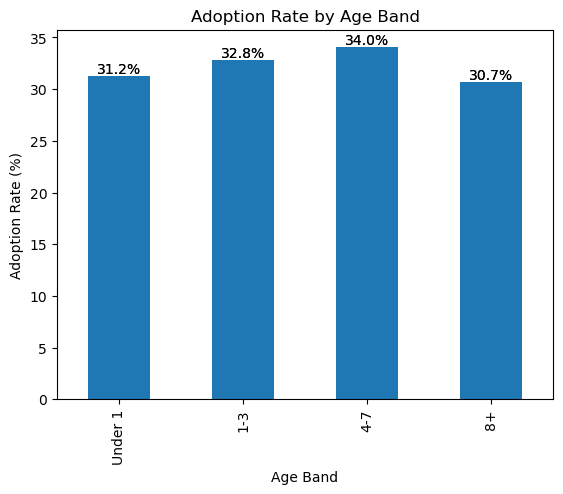

In [24]:
plot_age_summary['adoption_rate'].plot(
    kind='bar'
)

ax = plot_age_summary['adoption_rate'].plot(
    kind='bar'
)


plt.title('Adoption Rate by Age Band')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Age Band')

# Add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

In [25]:
age_band_summary = (
    adoption_df.groupby('age_band', observed=False)
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
age_band_summary['visit_dropout_rate'] = (
    age_band_summary['arranged_visit_rate']
    - age_band_summary['actual_visit_rate']
)

age_band_summary['visit_to_adoption_gap'] = (
    age_band_summary['actual_visit_rate']
    - age_band_summary['adoption_rate']
)

# format all rate columns
rate_age_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

age_band_summary[rate_age_columns] = (
    age_band_summary[rate_age_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

age_band_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
age_band,,,,,,,,,
Under 1,48,37,77.1%,28,58.3%,15,31.2%,18.8%,27.1%
1-3,64,55,85.9%,39,60.9%,21,32.8%,25.0%,28.1%
4-7,94,84,89.4%,66,70.2%,32,34.0%,19.1%,36.2%
8+,75,62,82.7%,45,60.0%,23,30.7%,22.7%,29.3%


In [26]:
adoption_by_age = (
    adoption_df
    .groupby('age_band', observed=False)
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)

adoption_by_age['adoption_rate'] = (
    adoption_by_age['adoption_rate']
    * 100
).round(1)
adoption_by_age

,adoption_rate
age_band,
Under 1,31.2
1-3,32.8
4-7,34.0
8+,30.7


Taking cats and dogs as a whole, adoption by age band is fairly flat, with the 4-7 age group having the largest adoption rate percentage of 34%, with animals over 8 years old having the smallest adoption rate percentage of 30.7%

In [27]:
dog_age_summary = (
    adoption_df[adoption_df['species']=='Dog']
    .groupby('age_years')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
dog_age_summary['visit_dropout_rate'] = (
    dog_age_summary['arranged_visit_rate']
    - dog_age_summary['actual_visit_rate']
)

dog_age_summary['visit_to_adoption_gap'] = (
    dog_age_summary['actual_visit_rate']
    - dog_age_summary['adoption_rate']
)

# format all rate columns
dog_rate_age_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

dog_age_summary[dog_rate_age_columns] = (
    dog_age_summary[dog_rate_age_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_age_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
age_years,,,,,,,,,
1.0,24,20,83.3%,15,62.5%,8,33.3%,20.8%,29.2%
2.0,12,10,83.3%,9,75.0%,4,33.3%,8.3%,41.7%
3.0,28,23,82.1%,16,57.1%,7,25.0%,25.0%,32.1%
4.0,10,10,100.0%,8,80.0%,4,40.0%,20.0%,40.0%
5.0,3,3,100.0%,3,100.0%,2,66.7%,0.0%,33.3%
6.0,19,17,89.5%,11,57.9%,7,36.8%,31.6%,21.1%
7.0,19,16,84.2%,13,68.4%,7,36.8%,15.8%,31.6%
8.0,10,10,100.0%,6,60.0%,2,20.0%,40.0%,40.0%
9.0,7,7,100.0%,4,57.1%,3,42.9%,42.9%,14.3%


In [28]:
dog_age_summary = (
    adoption_df[adoption_df['species']=='Dog']
    .groupby('age_years')
    .agg(
        total_animals=('animal_id', 'count'),
        adoption_rate=('adopted', 'mean')
    )
)

In [29]:
plot_dog_age_summary = dog_age_summary.copy()

plot_dog_age_summary['adoption_rate'] = (
    plot_dog_age_summary['adoption_rate']
    * 100
)

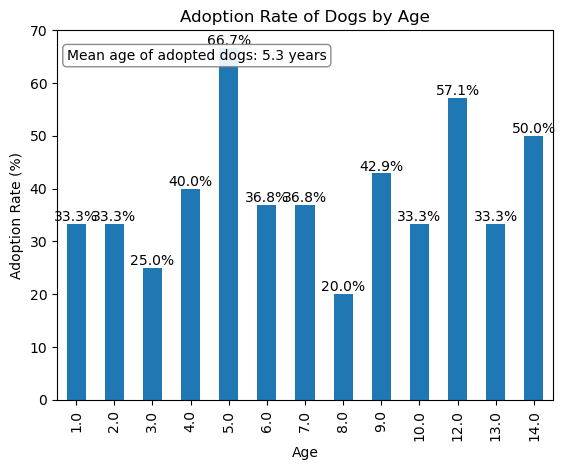

In [30]:
mean_age_dog = adoption_df.loc[
    adoption_df['species'] == 'Dog',
    'age_years'
].mean()

ax = plot_dog_age_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Adoption Rate of Dogs by Age')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Age')

# Add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.text(
    0.02,
    0.95,
    f'Mean age of adopted dogs: {mean_age_dog:.1f} years',
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='grey',
        alpha=0.9
    )
)

plt.show()

In [31]:
dog_age_band_summary = (
    adoption_df[adoption_df['species']=='Dog']
    .groupby('age_band', observed=False)
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
dog_age_band_summary['visit_dropout_rate'] = (
    dog_age_band_summary['arranged_visit_rate']
    - dog_age_band_summary['actual_visit_rate']
)

dog_age_band_summary['visit_to_adoption_gap'] = (
    dog_age_band_summary['actual_visit_rate']
    - dog_age_band_summary['adoption_rate']
)

# format all rate columns
dog_rate_age_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

dog_age_band_summary[dog_rate_age_columns] = (
    dog_age_band_summary[dog_rate_age_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_age_band_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
age_band,,,,,,,,,
Under 1,24,20,83.3%,15,62.5%,8,33.3%,20.8%,29.2%
1-3,40,33,82.5%,25,62.5%,11,27.5%,20.0%,35.0%
4-7,51,46,90.2%,35,68.6%,20,39.2%,21.6%,29.4%
8+,35,33,94.3%,23,65.7%,13,37.1%,28.6%,28.6%


In [32]:
dog_age_band_summary = (
    adoption_df[adoption_df['species']=='Dog']
    .groupby('age_band', observed=False)
    .agg(
        total_animals=('animal_id', 'count'),
        adoption_rate=('adopted', 'mean')
    )
)
dog_age_band_summary

,total_animals,adoption_rate
age_band,,
Under 1,24,0.333333
1-3,40,0.275000
4-7,51,0.392157
8+,35,0.371429


In [33]:
plot_dog_age_band_summary = dog_age_band_summary.copy()

plot_dog_age_band_summary['adoption_rate'] = (
    plot_dog_age_band_summary['adoption_rate']
    * 100
)

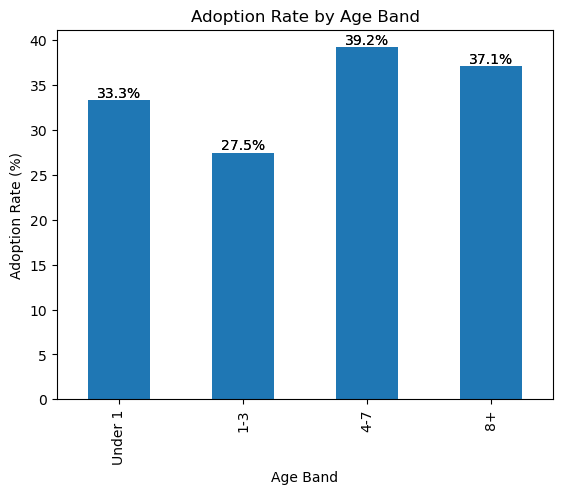

In [34]:
plot_dog_age_band_summary['adoption_rate'].plot(
    kind='bar'
)

ax = plot_dog_age_band_summary['adoption_rate'].plot(
    kind='bar'
)


plt.title('Adoption Rate by Age Band')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Age Band')

# Add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

In [35]:
cat_age_summary = (
    adoption_df[adoption_df['species']=='Cat'
    ]
    .groupby('age_years')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
cat_age_summary['visit_dropout_rate'] = (
    cat_age_summary['arranged_visit_rate']
    - cat_age_summary['actual_visit_rate']
)

cat_age_summary['visit_to_adoption_gap'] = (
    cat_age_summary['actual_visit_rate']
    - cat_age_summary['adoption_rate']
)

# format all rate columns
rate_cat_age_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

cat_age_summary[rate_cat_age_columns] = (
    cat_age_summary[rate_cat_age_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

cat_age_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
age_years,,,,,,,,,
1.0,24,17,70.8%,13,54.2%,7,29.2%,16.7%,25.0%
2.0,17,15,88.2%,9,52.9%,7,41.2%,35.3%,11.8%
3.0,7,7,100.0%,5,71.4%,3,42.9%,28.6%,28.6%
4.0,19,19,100.0%,17,89.5%,5,26.3%,10.5%,63.2%
5.0,10,8,80.0%,7,70.0%,3,30.0%,10.0%,40.0%
6.0,10,8,80.0%,6,60.0%,3,30.0%,20.0%,30.0%
7.0,4,3,75.0%,1,25.0%,1,25.0%,50.0%,0.0%
8.0,22,15,68.2%,10,45.5%,5,22.7%,22.7%,22.7%
9.0,6,4,66.7%,3,50.0%,1,16.7%,16.7%,33.3%


In [36]:
cat_age_summary = (
    adoption_df[adoption_df['species']=='Cat']
    .groupby('age_band', observed=False)
    .agg(
        total_animals=('animal_id', 'count'),
        adoption_rate=('adopted', 'mean')
    )
)

In [37]:
plot_cat_age_summary = cat_age_summary.copy()

plot_cat_age_summary['adoption_rate'] = (
    plot_cat_age_summary['adoption_rate']
    * 100
)

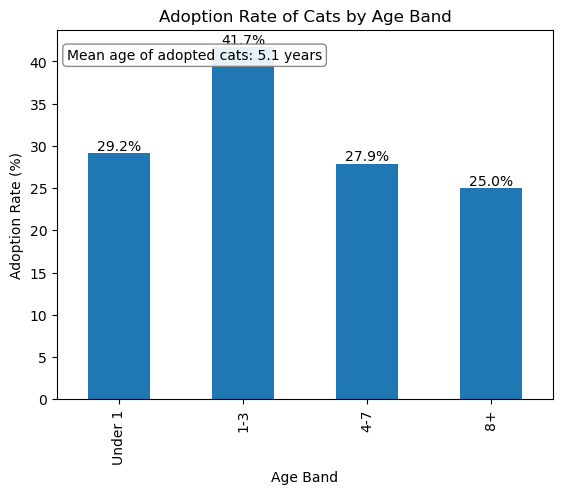

In [38]:
mean_age_cat = adoption_df.loc[
    adoption_df['species'] == 'Cat',
    'age_years'
].mean()

ax = plot_cat_age_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Adoption Rate of Cats by Age Band')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Age Band')

# Add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.text(
    0.02,
    0.95,
    f'Mean age of adopted cats: {mean_age_cat:.1f} years',
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='grey',
        alpha=0.9
    )
)

plt.show()

***
**health_status**

In [39]:
health_summary = (
    adoption_df
    .groupby('health_status', dropna=False)
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
health_summary['visit_dropout_rate'] = (
    health_summary['arranged_visit_rate']
    - health_summary['actual_visit_rate']
)

health_summary['visit_to_adoption_gap'] = (
    health_summary['actual_visit_rate']
    - health_summary['adoption_rate']
)

# format all rate columns
rate_health_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

health_summary[rate_health_columns] = (
    health_summary[rate_health_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)
health_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
health_status,,,,,,,,,
Chronic,25,21,84.0%,18,72.0%,7,28.0%,12.0%,44.0%
Good,179,151,84.4%,110,61.5%,62,34.6%,22.9%,26.8%
In Treatment,40,31,77.5%,23,57.5%,11,27.5%,20.0%,30.0%
Minor Issues,70,61,87.1%,47,67.1%,22,31.4%,20.0%,35.7%
Unknown,6,6,100.0%,5,83.3%,3,50.0%,16.7%,33.3%


In [40]:
plot_health_summary = (
    adoption_df.groupby('health_status')
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)

plot_health_summary['adoption_rate'] = (
    plot_health_summary['adoption_rate']
    * 100
)

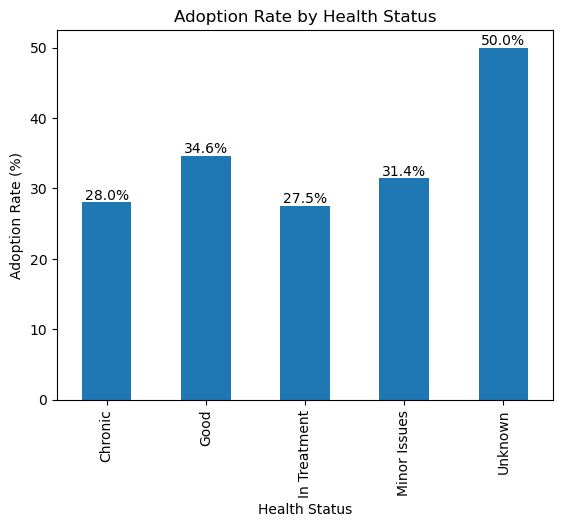

In [41]:
ax = plot_health_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Adoption Rate by Health Status')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Health Status')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

50% of adopted animals have unknown health conditions.  Health status was missing for a substantial proportion of adopted animals, limiting the strength of conclusions drawn from health-related analysis.  Animals with good health tend to be the highest adopted animals at 34.6%.  There is a marginal difference in adoption rates for animals with chronic and minor issues, with those currently in treatment having the lowest rate of adoption, at 27.5%.

***
**sex**

In [42]:
sex_summary = (
    adoption_df
    .groupby('sex', observed=False)
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)
sex_summary['adoption_rate'] = (
    sex_summary['adoption_rate']
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

sex_summary

,adoption_rate
sex,
F,35.1%
M,30.8%
Unknown,22.2%


In [43]:
sex_of_dog_summary = (
    adoption_df[
        adoption_df['species'] == 'Dog'
    ]
    .groupby('sex', observed=False)
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)
sex_of_dog_summary['adoption_rate'] = (
    sex_of_dog_summary['adoption_rate']
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

sex_of_dog_summary

,adoption_rate
sex,
F,37.8%
M,33.8%
Unknown,33.3%


In [44]:
adoption_df[
    adoption_df['species'] == 'Dog'
]['sex'].value_counts()

sex
F          90
M          71
Unknown     3
Name: count, dtype: int64

In [45]:
sex_of_cat_summary = (
    adoption_df[
        adoption_df['species'] == 'Cat'
    ]
    .groupby('sex', observed=False)
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)
sex_of_cat_summary['adoption_rate'] = (
    sex_of_cat_summary['adoption_rate']
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

sex_of_cat_summary

,adoption_rate
sex,
F,32.1%
M,27.8%
Unknown,16.7%


In [46]:
adoption_df[
    adoption_df['species'] == 'Cat'
]['sex'].value_counts()

sex
F          78
M          72
Unknown     6
Name: count, dtype: int64

Female dogs and female cats tend to be the highest adopted animals although the results for dogs are skewed by 33.33% being of unknown gender (vs 16.7% for cats).

***
### Enquiry Attributes

***
**channel**

In [47]:
channel_summary = (
    adoption_df
    .groupby('channel')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
channel_summary['visit_dropout_rate'] = (
    channel_summary['arranged_visit_rate']
    - channel_summary['actual_visit_rate']
)

channel_summary['visit_to_adoption_gap'] = (
    channel_summary['actual_visit_rate']
    - channel_summary['adoption_rate']
)

# format all rate columns
rate_channel_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

channel_summary[rate_channel_columns] = (
    channel_summary[rate_channel_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

channel_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
channel,,,,,,,,,
Email,41,34,82.9%,25,61.0%,9,22.0%,22.0%,39.0%
Facebook,30,22,73.3%,19,63.3%,12,40.0%,10.0%,23.3%
Phone,59,52,88.1%,34,57.6%,18,30.5%,30.5%,27.1%
Unknown,9,9,100.0%,6,66.7%,5,55.6%,33.3%,11.1%
Walk-In,18,16,88.9%,11,61.1%,4,22.2%,27.8%,38.9%
Website,163,137,84.0%,108,66.3%,57,35.0%,17.8%,31.3%


In [48]:
plot_channel_summary = (
    adoption_df.groupby('channel')
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)

plot_channel_summary['adoption_rate'] = (
    plot_channel_summary['adoption_rate']
    * 100
)

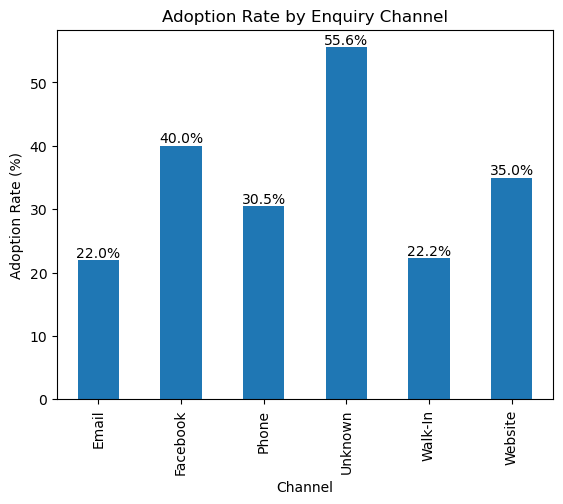

In [49]:
ax = plot_channel_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Adoption Rate by Enquiry Channel')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Channel')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

Website enquiries generate the greatest number of successful adoptions and appear to be the shelter’s most operationally important channel.

In [50]:
health_mix = (
    pd.crosstab(
        adoption_df['channel'],
        adoption_df['health_status'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)
health_mix

health_status,Chronic,Good,In Treatment,Minor Issues,Unknown
channel,,,,,
Email,12.2%,53.7%,9.8%,22.0%,2.4%
Facebook,3.3%,60.0%,10.0%,23.3%,3.3%
Phone,5.1%,59.3%,8.5%,27.1%,0.0%
Unknown,0.0%,77.8%,0.0%,22.2%,0.0%
Walk-In,5.6%,55.6%,11.1%,27.8%,0.0%
Website,9.2%,53.4%,16.0%,19.0%,2.5%


In [51]:
health_mix_counts = (
    pd.crosstab(
        adoption_df['channel'],
        adoption_df['health_status'], 
        margins=True,
        margins_name='Total'
    )
)
health_mix_counts

health_status,Chronic,Good,In Treatment,Minor Issues,Unknown,Total
channel,,,,,,
Email,5,22,4,9,1,41
Facebook,1,18,3,7,1,30
Phone,3,35,5,16,0,59
Unknown,0,7,0,2,0,9
Walk-In,1,10,2,5,0,18
Website,15,87,26,31,4,163
Total,25,179,40,70,6,320


In [52]:
cat_channel_summary = (
    adoption_df[adoption_df['species']=='Cat'
    ]
    .groupby('channel')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
cat_channel_summary['visit_dropout_rate'] = (
    cat_channel_summary['arranged_visit_rate']
    - cat_channel_summary['actual_visit_rate']
)

cat_channel_summary['visit_to_adoption_gap'] = (
    cat_channel_summary['actual_visit_rate']
    - cat_channel_summary['adoption_rate']
)

# format all rate columns
cat_rate_channel_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

cat_channel_summary[cat_rate_channel_columns] = (
    cat_channel_summary[cat_rate_channel_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

cat_channel_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
channel,,,,,,,,,
Email,14,11,78.6%,9,64.3%,4,28.6%,14.3%,35.7%
Facebook,18,11,61.1%,9,50.0%,5,27.8%,11.1%,22.2%
Phone,30,25,83.3%,17,56.7%,10,33.3%,26.7%,23.3%
Unknown,6,6,100.0%,4,66.7%,3,50.0%,33.3%,16.7%
Walk-In,8,8,100.0%,5,62.5%,0,0.0%,37.5%,62.5%
Website,80,65,81.2%,50,62.5%,24,30.0%,18.8%,32.5%


In absolute terms, website is delivering 2.4 times as many adopted cats as Facebook.

In [53]:
plot_cat_channel_summary = (
    adoption_df[adoption_df['species']=='Cat']
    .groupby('channel')
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)

plot_cat_channel_summary['adoption_rate'] = (
    plot_cat_channel_summary['adoption_rate']
    * 100
)

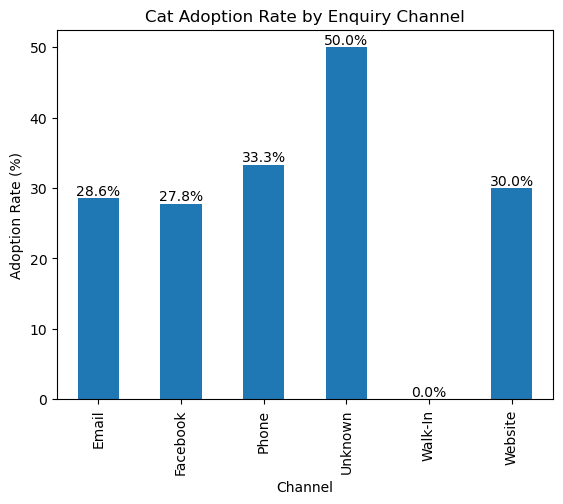

In [54]:
ax = plot_cat_channel_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Cat Adoption Rate by Enquiry Channel')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Channel')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

Which channel has a higher proportion of healthy cats?

In [55]:
cat_health_mix = (
    pd.crosstab(
        adoption_df[
            adoption_df['species'] == 'Cat'
        ]['channel'],
        adoption_df[
            adoption_df['species'] == 'Cat'
        ]['health_status'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

cat_health_mix

health_status,Chronic,Good,In Treatment,Minor Issues,Unknown
channel,,,,,
Email,14.3%,64.3%,7.1%,14.3%,0.0%
Facebook,0.0%,61.1%,11.1%,22.2%,5.6%
Phone,3.3%,60.0%,3.3%,33.3%,0.0%
Unknown,0.0%,83.3%,0.0%,16.7%,0.0%
Walk-In,12.5%,37.5%,12.5%,37.5%,0.0%
Website,13.8%,46.2%,16.2%,22.5%,1.2%


In [56]:
cat_health_mix_counts = (
    pd.crosstab(
        adoption_df[
            adoption_df['species'] == 'Cat'
        ]['channel'],
        adoption_df[
            adoption_df['species'] == 'Cat'
        ]['health_status'],
        margins=True,
        margins_name='Total'
    )
)

cat_health_mix_counts

health_status,Chronic,Good,In Treatment,Minor Issues,Unknown,Total
channel,,,,,,
Email,2,9,1,2,0,14
Facebook,0,11,2,4,1,18
Phone,1,18,1,10,0,30
Unknown,0,5,0,1,0,6
Walk-In,1,3,1,3,0,8
Website,11,37,13,18,1,80
Total,15,83,18,38,2,156


For cats with the same health condition, which channel peforms best?

In [57]:
cat_health_channel_adoption = (
    pd.pivot_table(
        adoption_df[
            adoption_df['species'] == 'Cat'
        ],
        index='health_status',
        columns='channel',
        values='adopted',
        aggfunc='mean'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

cat_health_channel_adoption

channel,Email,Facebook,Phone,Unknown,Walk-In,Website
health_status,,,,,,
Chronic,0.0%,nan%,0.0%,nan%,0.0%,36.4%
Good,44.4%,36.4%,27.8%,60.0%,0.0%,29.7%
In Treatment,0.0%,0.0%,0.0%,nan%,0.0%,23.1%
Minor Issues,0.0%,0.0%,50.0%,0.0%,0.0%,33.3%
Unknown,nan%,100.0%,nan%,nan%,nan%,0.0%


In [58]:
cat_health_channel_counts = (
    pd.pivot_table(
        adoption_df[
            adoption_df['species'] == 'Cat'
        ],
        index='health_status',
        columns='channel',
        values='animal_id',
        aggfunc='count'
    )
)

cat_health_channel_counts

channel,Email,Facebook,Phone,Unknown,Walk-In,Website
health_status,,,,,,
Chronic,2.0,NaN,1.0,NaN,1.0,11.0
Good,9.0,11.0,18.0,5.0,3.0,37.0
In Treatment,1.0,2.0,1.0,NaN,1.0,13.0
Minor Issues,2.0,4.0,10.0,1.0,3.0,18.0
Unknown,NaN,1.0,NaN,NaN,NaN,1.0


In [59]:
dog_channel_summary = (
    adoption_df[adoption_df['species']=='Dog'
    ]
    .groupby('channel')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
dog_channel_summary['visit_dropout_rate'] = (
    dog_channel_summary['arranged_visit_rate']
    - dog_channel_summary['actual_visit_rate']
)

dog_channel_summary['visit_to_adoption_gap'] = (
    dog_channel_summary['actual_visit_rate']
    - dog_channel_summary['adoption_rate']
)

# format all rate columns
dog_rate_channel_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

dog_channel_summary[dog_rate_channel_columns] = (
    dog_channel_summary[dog_rate_channel_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_channel_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
channel,,,,,,,,,
Email,27,23,85.2%,16,59.3%,5,18.5%,25.9%,40.7%
Facebook,12,11,91.7%,10,83.3%,7,58.3%,8.3%,25.0%
Phone,29,27,93.1%,17,58.6%,8,27.6%,34.5%,31.0%
Unknown,3,3,100.0%,2,66.7%,2,66.7%,33.3%,0.0%
Walk-In,10,8,80.0%,6,60.0%,4,40.0%,20.0%,20.0%
Website,83,72,86.7%,58,69.9%,33,39.8%,16.9%,30.1%


In absolute terms, website is delivering 4.7 times as many adopted dogs as Facebook.

In [60]:
plot_dog_channel_summary = (
    adoption_df[adoption_df['species']=='Dog']
    .groupby('channel')
    .agg(
        adoption_rate=('adopted', 'mean')
    )
)

plot_dog_channel_summary['adoption_rate'] = (
    plot_dog_channel_summary['adoption_rate']
    * 100
)

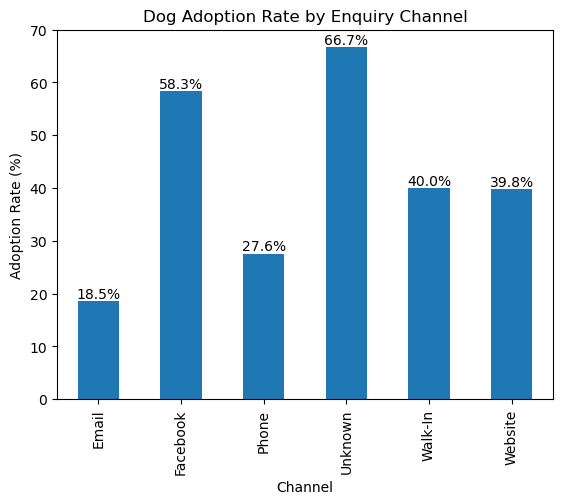

In [61]:
ax = plot_dog_channel_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Dog Adoption Rate by Enquiry Channel')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Channel')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

Does Facebook have a higher proportion of healthy dogs?

In [62]:
dog_health_mix = (
    pd.crosstab(
        adoption_df[
            adoption_df['species'] == 'Dog'
        ]['channel'],
        adoption_df[
            adoption_df['species'] == 'Dog'
        ]['health_status'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_health_mix

health_status,Chronic,Good,In Treatment,Minor Issues,Unknown
channel,,,,,
Email,11.1%,48.1%,11.1%,25.9%,3.7%
Facebook,8.3%,58.3%,8.3%,25.0%,0.0%
Phone,6.9%,58.6%,13.8%,20.7%,0.0%
Unknown,0.0%,66.7%,0.0%,33.3%,0.0%
Walk-In,0.0%,70.0%,10.0%,20.0%,0.0%
Website,4.8%,60.2%,15.7%,15.7%,3.6%


I also wanted a companion table of counts to see if any of the percentage figures would be skewed by low sample counts.

In [63]:
dog_health_mix_counts = (
    pd.crosstab(
        adoption_df[
            adoption_df['species'] == 'Dog'
        ]['channel'],
        adoption_df[
            adoption_df['species'] == 'Dog'
        ]['health_status'],
        margins=True,
        margins_name='Total'
    )
)

dog_health_mix_counts

health_status,Chronic,Good,In Treatment,Minor Issues,Unknown,Total
channel,,,,,,
Email,3,13,3,7,1,27
Facebook,1,7,1,3,0,12
Phone,2,17,4,6,0,29
Unknown,0,2,0,1,0,3
Walk-In,0,7,1,2,0,10
Website,4,50,13,13,3,83
Total,10,96,22,32,4,164


For dogs with the same health condition, which channel peforms best?

In [64]:
dog_health_channel_adoption = (
    pd.pivot_table(
        adoption_df[
            adoption_df['species'] == 'Dog'
        ],
        index='health_status',
        columns='channel',
        values='adopted',
        aggfunc='mean'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_health_channel_adoption

channel,Email,Facebook,Phone,Unknown,Walk-In,Website
health_status,,,,,,
Chronic,33.3%,100.0%,0.0%,nan%,nan%,25.0%
Good,23.1%,57.1%,35.3%,100.0%,28.6%,36.0%
In Treatment,0.0%,0.0%,0.0%,nan%,0.0%,61.5%
Minor Issues,14.3%,66.7%,33.3%,0.0%,100.0%,30.8%
Unknown,0.0%,nan%,nan%,nan%,nan%,66.7%


In [65]:
dog_health_channel_counts = (
    pd.pivot_table(
        adoption_df[
            adoption_df['species'] == 'Dog'
        ],
        index='health_status',
        columns='channel',
        values='animal_id',
        aggfunc='count'
    )
)

dog_health_channel_counts

channel,Email,Facebook,Phone,Unknown,Walk-In,Website
health_status,,,,,,
Chronic,3.0,1.0,2.0,NaN,NaN,4.0
Good,13.0,7.0,17.0,2.0,7.0,50.0
In Treatment,3.0,1.0,4.0,NaN,1.0,13.0
Minor Issues,7.0,3.0,6.0,1.0,2.0,13.0
Unknown,1.0,NaN,NaN,NaN,NaN,3.0


In absolute terms, the website is delivering 3.2 times more adopted animals than telephone, and 4.75 times more adopted animals than Facebook.   The Facebook adoption rate of 40% appears high, but this only accounts for 12 adopted animals out of 30.  The Facebook channel also has a higher proportion of healthy animals at 60%, but this is predominantly driven by the low sample size.  The email channel has a higher proportion of healthy cats at 64.3%, or 9 out of 14, with Facebook and phone achieving rates of healthy cats over 60%.  7 out of 10 dogs are of good health in the walk-in channel, with 60% of healthy dogs represented by the website channel.  

Website enquiries generated a lower adoption rate than Facebook (35.0%) but represented a substantially larger population (163 animals), making the result more reliable and operationally significant.  

Potentially, Facebook could be a promising channel that warrants further monitoring however the website appears to be the shelter's primary adoption channel, delivering the largest volume of successful adoptions and consistently strong performance across health categories.

***
**response_time**

In [66]:
adoption_df['response_time_hours'].describe()

count    264.000000
mean      20.359848
std       26.157814
min        1.000000
25%        6.000000
50%       12.000000
75%       21.000000
max      120.000000
Name: response_time_hours, dtype: float64

In [67]:
adoption_df['response_time_bands'] = pd.cut(
    adoption_df['response_time_hours'],
    bins=[-1, 24, 48, 72, 96,120],
    labels=[
        '0-1 day',
        '1-2 days',
        '2-3 days',
        '3-4 days',
        '4+ days'
    ]
)

In [68]:
adoption_df.head()

,enquiry_id,animal_id,customer_id,enquiry_date,channel,response_time_hours,enquiry_status,name,species,breed,...,returned_within_30_days,return_date,adopted,days_enquiry_to_adoption,days_visit_to_adoption,days_adoption_to_return,had_visit,attended_visit,age_band,response_time_bands
0,E0001,A115,C0369,2025-04-12 00:00:00,Walk-In,8.0,Closed,Luna,Cat,Tabby,...,NaN,NaN,0,NaN,NaN,NaN,1,0,1-3,0-1 day
1,E0002,A121,C0296,2025-03-29 00:00:00,Facebook,10.0,Open,Sasha,Cat,Domestic Longhair,...,No,NaN,1,16.0,9.0,NaN,1,1,1-3,0-1 day
2,E0003,A095,C0288,2025-03-17 00:00:00,Website,26.0,Closed,Ruby,Cat,Maine Coon,...,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,1-2 days
3,E0004,A030,C0122,2025-02-13 00:00:00,Email,34.0,Closed,Rocky,Dog,German Shepherd,...,NaN,NaN,0,NaN,NaN,NaN,1,0,4-7,1-2 days
4,E0005,A011,C0149,2025-03-22 00:00:00,Website,7.0,Closed,Milo,Dog,Beagle,...,No,NaN,1,16.0,7.0,NaN,1,1,1-3,0-1 day


In [69]:
plot_response_summary = (
    adoption_df
    .groupby('response_time_bands', observed=False)
    .agg(adoption_rate=('adopted', 'mean'))
)

plot_response_summary['adoption_rate'] = (
    plot_response_summary['adoption_rate']
    .mul(100)
    .round(1)
)
response_summary = plot_response_summary.copy()

response_summary['adoption_rate'] = (
    response_summary['adoption_rate']
    .astype(str)
    + '%'
)
response_summary

,adoption_rate
response_time_bands,
0-1 day,33.3%
1-2 days,18.5%
2-3 days,0.0%
3-4 days,66.7%
4+ days,38.5%


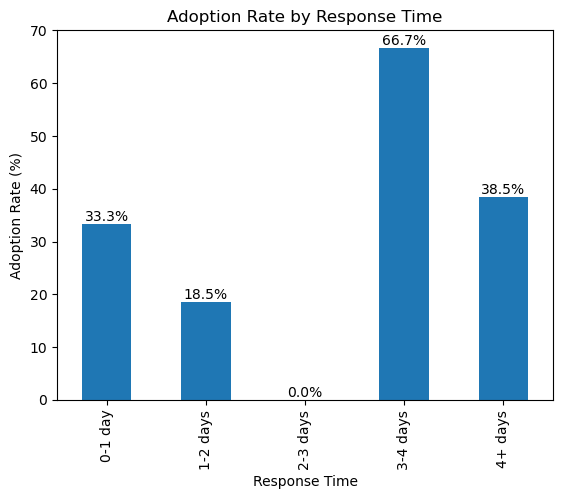

In [70]:
ax = plot_response_summary['adoption_rate'].plot(
    kind='bar'
)

plt.title('Adoption Rate by Response Time')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Response Time')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

Response time looks suspicious as we would expect faster response -> more engagement -> more visits -> more adoptions.

In [71]:
response_time_summary = (
    adoption_df
    .groupby('response_time_bands', observed=False)
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
)

# create gap metrics 
response_time_summary['visit_dropout_rate'] = (
    response_time_summary['arranged_visit_rate']
    - response_time_summary['actual_visit_rate']
)

response_time_summary['visit_to_adoption_gap'] = (
    response_time_summary['actual_visit_rate']
    - response_time_summary['adoption_rate']
)

# format all rate columns
rate_time_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap'
]

response_time_summary[rate_time_columns] = (
    response_time_summary[rate_time_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

response_time_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,visit_dropout_rate,visit_to_adoption_gap
response_time_bands,,,,,,,,,
0-1 day,213,180,84.5%,132,62.0%,71,33.3%,22.5%,28.6%
1-2 days,27,24,88.9%,17,63.0%,5,18.5%,25.9%,44.4%
2-3 days,2,2,100.0%,1,50.0%,0,0.0%,50.0%,50.0%
3-4 days,9,9,100.0%,9,100.0%,6,66.7%,0.0%,33.3%
4+ days,13,11,84.6%,9,69.2%,5,38.5%,15.4%,30.8%


We can see why the 3-4 day response adoption rate is so high at 66.7% - it is because of the 9 enquiries with a response time of 3-4, 6 animals were adopted.

In [72]:
response_analysis = (
adoption_df.loc[
(adoption_df['response_time_bands']=='3-4 days')&(adoption_df['adopted']==1), 
['species', 'colour', 'sex', 'health_status', 'age_band', 'adopted']
]
)
response_analysis

,species,colour,sex,health_status,age_band,adopted
55,Dog,Grey,F,Good,1-3,1
64,Dog,Black,M,Good,4-7,1
99,Dog,Brindle,Unknown,Good,8+,1
227,Cat,Calico,M,Good,1-3,1
252,Dog,Black & White,M,Unknown,1-3,1
299,Dog,Grey,F,Minor Issues,Under 1,1


Now we focus on overall response times regardless of whether adoption occurred or not.

In [73]:
response_species = (
    pd.crosstab(
        adoption_df['response_time_bands'],
        adoption_df['species'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .astype(str)
    + '%'
)

response_species

species,Cat,Dog
response_time_bands,,
0-1 day,53.05%,46.95%
1-2 days,33.33%,66.67%
2-3 days,0.0%,100.0%
3-4 days,44.44%,55.56%
4+ days,30.77%,69.23%


In [74]:
response_species_count = (
    pd.crosstab(
        adoption_df['response_time_bands'],
        adoption_df['species'],
    )
)

response_species_count

species,Cat,Dog
response_time_bands,,
0-1 day,113,100
1-2 days,9,18
2-3 days,0,2
3-4 days,4,5
4+ days,4,9


In [75]:
adoption_df.groupby('adopted')['response_time_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
adopted,,,,,,,,
0,177.0,19.372881,24.065180,1.0,6.0,11.0,21.0,118.0
1,87.0,22.367816,30.019805,1.0,7.0,12.0,20.0,120.0


<Axes: title={'center': 'response_time_hours'}, xlabel='adopted'>

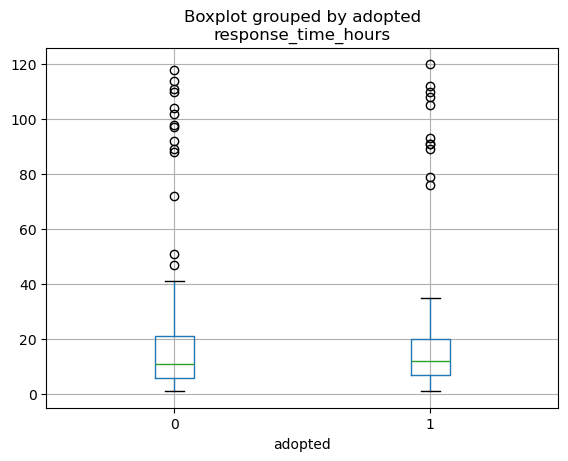

In [76]:
adoption_df.boxplot(
    column='response_time_hours',
    by='adopted'
)

Successful adoption rates are also clearly driven by response times, an initial review of the data suggests an optimal response time of 3-4 days.  However, the rate was high because 6 animals were adopted out of the 9 enquiries with a response time of 3-4 days (including two grey dogs which we know from earlier investigation to be a preferred adoption choice).  Close inspection reveals that at least 75% of responses leading to adoption were dealt with in around 20 hours.  Responses within 24 hours led to adoption rates almost twice as high as those with a 1-2 day response rate. The adoption rate of 38.5% for responses over 4 days is skewed by the sample size being small, at 5 adoptions out of 13 animals.

***
### Visit attributes

In [77]:
adoption_df['total_visits'].describe()

count    270.000000
mean       1.340741
std        0.593183
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        3.000000
Name: total_visits, dtype: float64

In [78]:
adoption_df['attended_visits'].describe()

count    270.000000
mean       0.948148
std        0.714362
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: attended_visits, dtype: float64

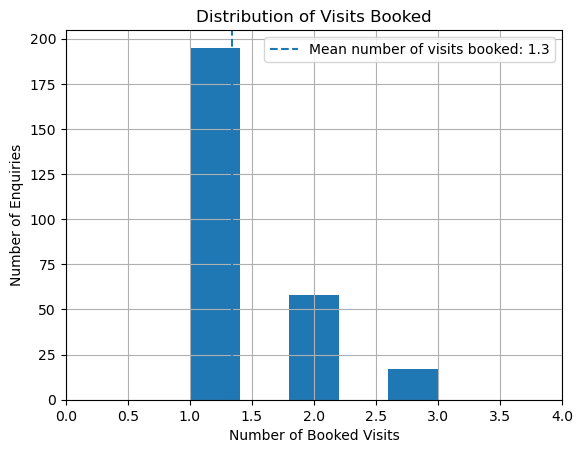

In [79]:
adoption_df["total_visits"].hist(bins=5)

plt.axvline(
    adoption_df["total_visits"].mean(),
    linestyle="--",
    label=f"Mean number of visits booked: {adoption_df['total_visits'].mean():.1f}"
)

plt.title("Distribution of Visits Booked")
plt.xlabel("Number of Booked Visits")
plt.ylabel("Number of Enquiries")

plt.xlim(0, 4)

plt.legend()

plt.show()

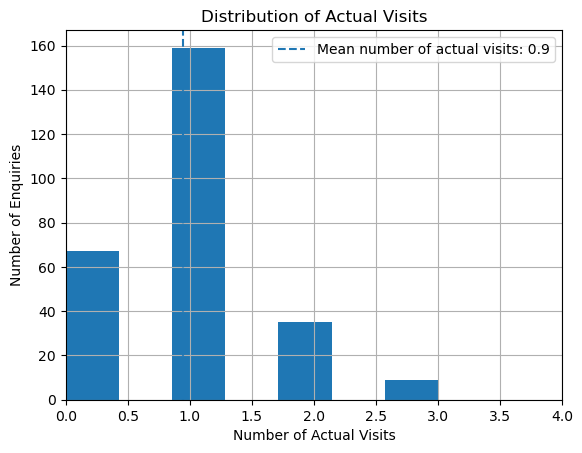

In [80]:
adoption_df["attended_visits"].hist(bins=7)

plt.axvline(
    adoption_df["attended_visits"].mean(),
    linestyle="--",
    label=f"Mean number of actual visits: {adoption_df['attended_visits'].mean():.1f}"
)

plt.title("Distribution of Actual Visits")
plt.xlabel("Number of Actual Visits")
plt.ylabel("Number of Enquiries")

plt.xlim(0, 4)

plt.legend()

plt.show()

In [81]:
visit_summary = (
    adoption_df
    .groupby('total_visits')
    .agg(
        total_enquiries=('enquiry_id', 'count'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )

)

visit_summary

,total_enquiries,adopted,adoption_rate
total_visits,,,
1.0,195,73,0.374359
2.0,58,24,0.413793
3.0,17,8,0.470588


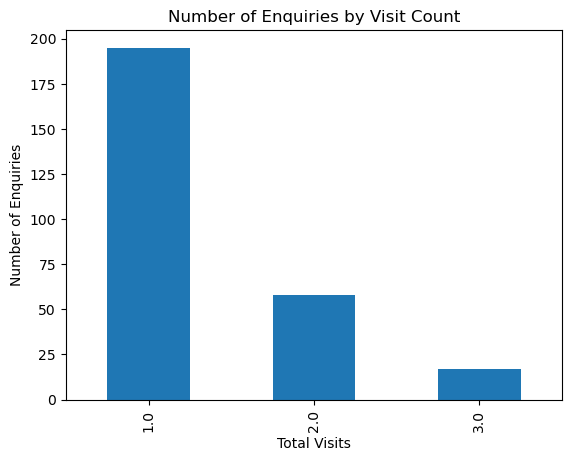

In [82]:
visit_summary['total_enquiries'].plot(
    kind='bar'
)

plt.title('Number of Enquiries by Visit Count')
plt.xlabel('Total Visits')
plt.ylabel('Number of Enquiries')

plt.show()

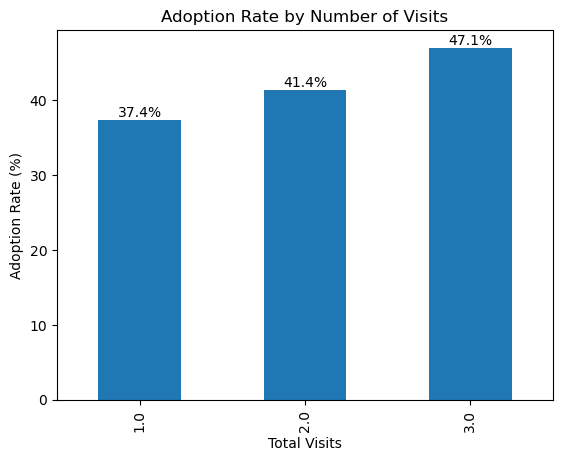

In [83]:
plot_visit_summary = visit_summary.copy()

plot_visit_summary['adoption_rate'] *= 100

ax = plot_visit_summary['adoption_rate'].plot(
    kind='bar'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Adoption Rate by Number of Visits')
plt.xlabel('Total Visits')
plt.ylabel('Adoption Rate (%)')

plt.show()

The mean number of visits booked after initial enquiry was 1.3, dropping to 0.9 actual visits.  The number of visits that led to higher adoption rates was 3 however this rate is skewed again by the size of the sample, where 8 animals were adopted out of 17 enquiries.  Two visits resulted in an adoption rate of 41.4% with one visit resulting in an adoption rate of 37.5%, suggesting that follow-up visits should be encouraged for uncertain adopters.

***
### Time metrics

In [84]:
adoption_df['days_enquiry_to_adoption'].describe()

count    105.000000
mean      18.819048
std        7.082998
min        5.000000
25%       14.000000
50%       19.000000
75%       24.000000
max       34.000000
Name: days_enquiry_to_adoption, dtype: float64

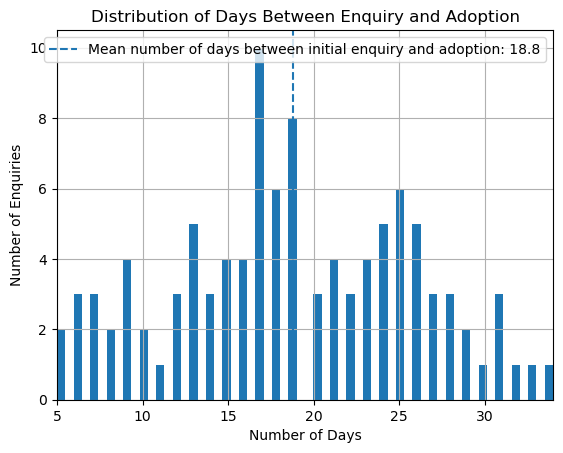

In [85]:
adoption_df["days_enquiry_to_adoption"].hist(bins=60)

plt.axvline(
    adoption_df["days_enquiry_to_adoption"].mean(),
    linestyle="--",
    label=f"Mean number of days between initial enquiry and adoption: {adoption_df['days_enquiry_to_adoption'].mean():.1f}"
)

plt.title("Distribution of Days Between Enquiry and Adoption")
plt.xlabel("Number of Days")
plt.ylabel("Number of Enquiries")

plt.xlim(5, 34)

plt.legend()

plt.show()

In [86]:
adoption_df['days_visit_to_adoption'].describe()

count    105.000000
mean      10.390476
std        5.859731
min        1.000000
25%        5.000000
50%       10.000000
75%       16.000000
max       21.000000
Name: days_visit_to_adoption, dtype: float64

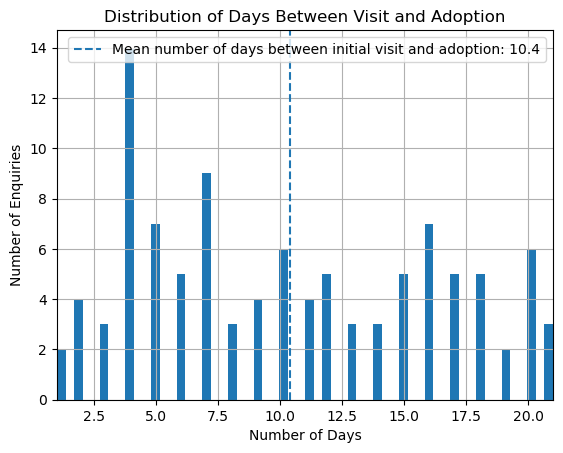

In [87]:
adoption_df["days_visit_to_adoption"].hist(bins=58)

plt.axvline(
    adoption_df["days_visit_to_adoption"].mean(),
    linestyle="--",
    label=f"Mean number of days between initial visit and adoption: {adoption_df['days_visit_to_adoption'].mean():.1f}"
)

plt.title("Distribution of Days Between Visit and Adoption")
plt.xlabel("Number of Days")
plt.ylabel("Number of Enquiries")

plt.xlim(1, 21)

plt.legend()

plt.show()

The average number of days between initial enquiry and adoption was 18.8 days, with an average of 10.4 between initial visit and adoption, leading to an average overall adoption time frame of 29.2 
days.


In [88]:
adoption_df['days_adoption_to_return'].describe()

count    15.000000
mean     15.466667
std       7.576907
min       3.000000
25%       9.000000
50%      15.000000
75%      22.000000
max      27.000000
Name: days_adoption_to_return, dtype: float64

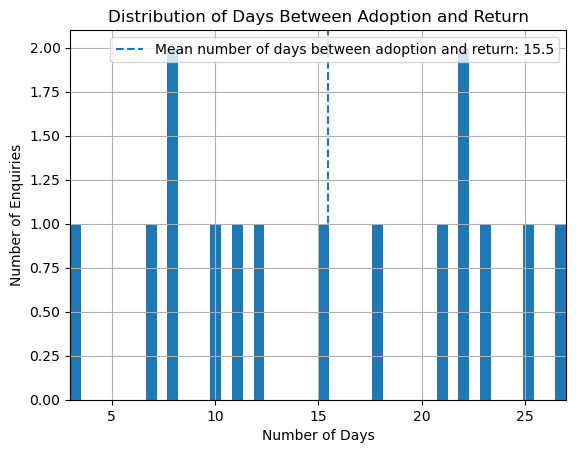

In [89]:
adoption_df["days_adoption_to_return"].hist(bins=46)

plt.axvline(
    adoption_df["days_adoption_to_return"].mean(),
    linestyle="--",
    label=f"Mean number of days between adoption and return: {adoption_df['days_adoption_to_return'].mean():.1f}"
)

plt.title("Distribution of Days Between Adoption and Return")
plt.xlabel("Number of Days")
plt.ylabel("Number of Enquiries")

plt.xlim(3, 27)

plt.legend()

plt.show()

In [90]:
adoption_rate_by_visit = (
    adoption_df
    .groupby('attended_visits', observed=False)
    .agg(adoption_rate=('adopted', 'mean')
    )

    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)
adoption_rate_by_visit

,adoption_rate
attended_visits,
0.0,0.0%
1.0,52.2%
2.0,48.6%
3.0,55.6%


In [91]:
visit_summary = (
    adoption_df
    .groupby('attended_visits')
    .agg(
        total_animals=('animal_id', 'count'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
    
)

visit_summary

,total_animals,adopted,adoption_rate
attended_visits,,,
0.0,67,0,0.000000
1.0,159,83,0.522013
2.0,35,17,0.485714
3.0,9,5,0.555556


In [92]:
plot_adoption_rate_by_visit = visit_summary.copy()

plot_adoption_rate_by_visit['adoption_rate'] = (
    plot_adoption_rate_by_visit['adoption_rate'] * 100
)

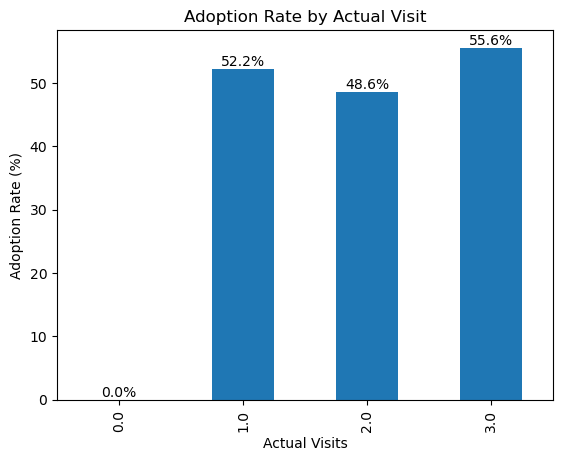

In [93]:
ax = plot_adoption_rate_by_visit['adoption_rate'].plot(
    kind='bar'
)

plt.title('Adoption Rate by Actual Visit')
plt.ylabel('Adoption Rate (%)')
plt.xlabel('Actual Visits')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.show()

Animals receiving three attended visits recorded the highest adoption rate (55.6%), however this was based on only nine animals and is therefore not considered statistically robust.  The majority of successful adoptions occurred after a single attended visit, which accounted for 83 adoptions and an adoption rate of 52.2%

1 attended visit -> 159 animals -> 83 adoptions -> 52.2% conversion suggests that most adopters make their decisions after one visit.  79% of all adoptions (83 out of 105) came from this group.

Of animals that were adopted, what percentage were returned within 30 days, and were there any health reasons that may have driven this?

In [94]:
adopted_animals = adoption_df[
    adoption_df['returned_within_30_days'].notna()
]

return_rate_by_health = (
    pd.crosstab(
        adopted_animals['health_status'],
        adopted_animals['returned_within_30_days'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

return_rate_by_health

returned_within_30_days,No,Unknown,Yes
health_status,,,
Chronic,71.4%,14.3%,14.3%
Good,80.6%,6.5%,12.9%
In Treatment,72.7%,9.1%,18.2%
Minor Issues,77.3%,4.5%,18.2%
Unknown,100.0%,0.0%,0.0%


In [95]:
pd.crosstab(
    adopted_animals['health_status'],
    adopted_animals['returned_within_30_days'],
    margins=True
)

returned_within_30_days,No,Unknown,Yes,All
health_status,,,,
Chronic,5,1,1,7
Good,50,4,8,62
In Treatment,8,1,2,11
Minor Issues,17,1,4,22
Unknown,3,0,0,3
All,83,7,15,105


In [96]:
adopted_animals = adoption_df[
    adoption_df['returned_within_30_days'].notna()
]

return_rate_by_age = (
    pd.crosstab(
        adopted_animals['age_years'],
        adopted_animals['returned_within_30_days'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

return_rate_by_age

returned_within_30_days,No,Unknown,Yes
age_years,,,
1.0,86.7%,0.0%,13.3%
2.0,63.6%,18.2%,18.2%
3.0,80.0%,0.0%,20.0%
4.0,66.7%,11.1%,22.2%
5.0,80.0%,0.0%,20.0%
6.0,80.0%,10.0%,10.0%
7.0,87.5%,12.5%,0.0%
8.0,85.7%,14.3%,0.0%
9.0,75.0%,0.0%,25.0%


In [97]:
pd.crosstab(
    adopted_animals['age_years'],
    adopted_animals['returned_within_30_days'],
    margins=True
)

returned_within_30_days,No,Unknown,Yes,All
age_years,,,,
1.0,13,0,2,15
2.0,7,2,2,11
3.0,8,0,2,10
4.0,6,1,2,9
5.0,4,0,1,5
6.0,8,1,1,10
7.0,7,1,0,8
8.0,6,1,0,7
9.0,3,0,1,4


In [98]:
adopted_animals = adoption_df[
    adoption_df['returned_within_30_days'].notna()
]

return_rate_by_age_band = (
    pd.crosstab(
        adopted_animals['age_band'],
        adopted_animals['returned_within_30_days'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

return_rate_by_age_band

returned_within_30_days,No,Unknown,Yes
age_band,,,
Under 1,86.7%,0.0%,13.3%
1-3,71.4%,9.5%,19.0%
4-7,78.1%,9.4%,12.5%
8+,78.3%,8.7%,13.0%


In [99]:
pd.crosstab(
    adopted_animals['age_band'],
    adopted_animals['returned_within_30_days'],
    margins=True
)

returned_within_30_days,No,Unknown,Yes,All
age_band,,,,
Under 1,13,0,2,15
1-3,15,2,4,21
4-7,25,3,4,32
8+,18,2,3,23
All,71,7,13,91


In [100]:
adopted_animals = adoption_df[
    adoption_df['returned_within_30_days'].notna()
]

return_rate_by_channel = (
    pd.crosstab(
        adopted_animals['channel'],
        adopted_animals['returned_within_30_days'],
        normalize='index'
    )
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

return_rate_by_channel

returned_within_30_days,No,Unknown,Yes
channel,,,
Email,66.7%,11.1%,22.2%
Facebook,58.3%,8.3%,33.3%
Phone,83.3%,11.1%,5.6%
Unknown,100.0%,0.0%,0.0%
Walk-In,100.0%,0.0%,0.0%
Website,80.7%,5.3%,14.0%


In [101]:
pd.crosstab(
    adopted_animals['channel'],
    adopted_animals['returned_within_30_days'],
    margins=True
)

returned_within_30_days,No,Unknown,Yes,All
channel,,,,
Email,6,1,2,9
Facebook,7,1,4,12
Phone,15,2,1,18
Unknown,5,0,0,5
Walk-In,4,0,0,4
Website,46,3,8,57
All,83,7,15,105


***
### Adoption speed

In [102]:
adoption_df.groupby('health_status')[
    'days_enquiry_to_adoption'
].median()

health_status
Chronic         19.0
Good            17.0
In Treatment    18.0
Minor Issues    21.0
Unknown         16.0
Name: days_enquiry_to_adoption, dtype: float64

In [103]:
adoption_df.groupby('age_band')[
    'days_enquiry_to_adoption'
].median()

/var/folders/83/h90r5k8d66zgjbj71_g0p_qm0000gn/T/ipykernel_19006/1084861143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adoption_df.groupby('age_band')[


age_band
Under 1    19.0
1-3        18.0
4-7        17.0
8+         23.0
Name: days_enquiry_to_adoption, dtype: float64

In [104]:
adoption_df.groupby('species')[
    'days_enquiry_to_adoption'
].median()

species
Cat    19.0
Dog    17.0
Name: days_enquiry_to_adoption, dtype: float64

Animals with minor health issues tend to stay in the shelter the longest, at 4 days more than those in good health.  Animals aged over 8 years old are also likely to ensure longer stays (23 days), with the optimum age-band being 4-7, staying in the shelter for 17.  Cats are also likely to stay longer than dogs, on average 19 days vs 17.

***
### Grey dogs

In [105]:
adoption_df['returned_animal'] = (
    adoption_df['return_date']
    .notna()
    .astype(int)
)

In [106]:
adoption_df.head()

,enquiry_id,animal_id,customer_id,enquiry_date,channel,response_time_hours,enquiry_status,name,species,breed,...,return_date,adopted,days_enquiry_to_adoption,days_visit_to_adoption,days_adoption_to_return,had_visit,attended_visit,age_band,response_time_bands,returned_animal
0,E0001,A115,C0369,2025-04-12 00:00:00,Walk-In,8.0,Closed,Luna,Cat,Tabby,...,NaN,0,NaN,NaN,NaN,1,0,1-3,0-1 day,0
1,E0002,A121,C0296,2025-03-29 00:00:00,Facebook,10.0,Open,Sasha,Cat,Domestic Longhair,...,NaN,1,16.0,9.0,NaN,1,1,1-3,0-1 day,0
2,E0003,A095,C0288,2025-03-17 00:00:00,Website,26.0,Closed,Ruby,Cat,Maine Coon,...,NaN,0,NaN,NaN,NaN,0,0,NaN,1-2 days,0
3,E0004,A030,C0122,2025-02-13 00:00:00,Email,34.0,Closed,Rocky,Dog,German Shepherd,...,NaN,0,NaN,NaN,NaN,1,0,4-7,1-2 days,0
4,E0005,A011,C0149,2025-03-22 00:00:00,Website,7.0,Closed,Milo,Dog,Beagle,...,NaN,1,16.0,7.0,NaN,1,1,1-3,0-1 day,0


In [107]:
dog_colour_summary = (
    adoption_df[
        adoption_df['species'] == 'Dog'
    ]
    .groupby('colour')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean'),
        returned=('returned_animal', 'sum'),
        returned_rate=('returned_animal', 'mean')       
    )
)

# create gap metrics 
dog_colour_summary['visit_dropout_rate'] = (
    dog_colour_summary['arranged_visit_rate']
    - dog_colour_summary['actual_visit_rate']
)

dog_colour_summary['visit_to_adoption_gap'] = (
    dog_colour_summary['actual_visit_rate']
    - dog_colour_summary['adoption_rate']
)

# format all rate columns
rate_dog_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap',
    'returned_rate'
]

dog_colour_summary[rate_dog_columns] = (
    dog_colour_summary[rate_dog_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

dog_colour_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,returned,returned_rate,visit_dropout_rate,visit_to_adoption_gap
colour,,,,,,,,,,,
Black,30,28,93.3%,22,73.3%,10,33.3%,2,6.7%,20.0%,40.0%
Black & White,12,10,83.3%,7,58.3%,4,33.3%,1,8.3%,25.0%,25.0%
Brindle,4,3,75.0%,3,75.0%,2,50.0%,1,25.0%,0.0%,25.0%
Brown,18,16,88.9%,13,72.2%,5,27.8%,1,5.6%,16.7%,44.4%
Cream,20,18,90.0%,11,55.0%,7,35.0%,0,0.0%,35.0%,20.0%
Ginger,10,10,100.0%,5,50.0%,3,30.0%,0,0.0%,50.0%,20.0%
Grey,15,10,66.7%,10,66.7%,7,46.7%,0,0.0%,0.0%,20.0%
Unknown,39,35,89.7%,27,69.2%,14,35.9%,1,2.6%,20.5%,33.3%
White,16,14,87.5%,11,68.8%,7,43.8%,1,6.2%,18.8%,25.0%


In [108]:
dog_return_analysis = (
adoption_df.loc[
(adoption_df['colour']=='Black')&(adoption_df['returned_animal']>0)&(adoption_df['species']=='Dog'), 
['species', 'colour', 'sex', 'health_status', 'age_band', 'returned_animal']
]
)
dog_return_analysis

,species,colour,sex,health_status,age_band,returned_animal
39,Dog,Black,M,Good,8+,1
214,Dog,Black,F,Good,4-7,1


The return rate of grey dogs is zero, which suggests that people who enquire about grey dogs are more serious adopters, although most of the grey dogs adopted out were in good health, with 3 out of 7 being at the optimum age range for adoption.

Brindle dogs had the highest return rate at 25% however this appears to be because only one of the four Brindle dogs adopted out were returned.  Instead we should look to black dogs being the more likely colour to be returned although in absolute terms, this related to only 2 in 10.  These returned dogs were in good health and at the preferred age bands for adoption, suggesting alternative reasons for return.

In [109]:
cat_colour_summary = (
    adoption_df[
        adoption_df['species'] == 'Cat'
    ]
    .groupby('colour')
    .agg(
        total_animals=('animal_id', 'count'),
        arranged_visit=('had_visit', 'sum'),
        arranged_visit_rate=('had_visit', 'mean'),
        actual_visit=('attended_visit', 'sum'),
        actual_visit_rate=('attended_visit', 'mean'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean'),
        returned=('returned_animal', 'sum'),
        returned_rate=('returned_animal', 'mean')       
    )
)

# create gap metrics 
cat_colour_summary['visit_dropout_rate'] = (
    cat_colour_summary['arranged_visit_rate']
    - cat_colour_summary['actual_visit_rate']
)

cat_colour_summary['visit_to_adoption_gap'] = (
    cat_colour_summary['actual_visit_rate']
    - cat_colour_summary['adoption_rate']
)

# format all rate columns
rate_cat_columns = [
    'arranged_visit_rate',
    'actual_visit_rate',
    'adoption_rate',
    'visit_dropout_rate',
    'visit_to_adoption_gap',
    'returned_rate'
]

cat_colour_summary[rate_cat_columns] = (
    cat_colour_summary[rate_cat_columns]
    .mul(100)
    .round(1)
    .astype(str)
    + '%'
)

cat_colour_summary

,total_animals,arranged_visit,arranged_visit_rate,actual_visit,actual_visit_rate,adopted,adoption_rate,returned,returned_rate,visit_dropout_rate,visit_to_adoption_gap
colour,,,,,,,,,,,
Black,22,16,72.7%,13,59.1%,7,31.8%,2,9.1%,13.6%,27.3%
Black & White,15,14,93.3%,9,60.0%,5,33.3%,2,13.3%,33.3%,26.7%
Brindle,11,9,81.8%,4,36.4%,2,18.2%,0,0.0%,45.5%,18.2%
Brown,11,8,72.7%,5,45.5%,4,36.4%,0,0.0%,27.3%,9.1%
Calico,16,15,93.8%,13,81.2%,6,37.5%,0,0.0%,12.5%,43.8%
Cream,9,6,66.7%,6,66.7%,2,22.2%,0,0.0%,0.0%,44.4%
Ginger,19,16,84.2%,12,63.2%,5,26.3%,1,5.3%,21.1%,36.8%
Grey,10,8,80.0%,5,50.0%,3,30.0%,0,0.0%,30.0%,20.0%
Tabby,25,20,80.0%,18,72.0%,7,28.0%,2,8.0%,8.0%,44.0%


In [110]:
grey_dog_analysis = (
adoption_df.loc[
(adoption_df['colour']=='Grey')&(adoption_df['species']=='Dog')&(adoption_df['adopted']==1), 
['species', 'colour', 'sex', 'health_status', 'age_band', 'adopted']
]
)
grey_dog_analysis

,species,colour,sex,health_status,age_band,adopted
12,Dog,Grey,M,Good,NaN,1
20,Dog,Grey,F,Good,8+,1
55,Dog,Grey,F,Good,1-3,1
61,Dog,Grey,F,Good,4-7,1
81,Dog,Grey,F,Good,1-3,1
263,Dog,Grey,F,Good,4-7,1
299,Dog,Grey,F,Minor Issues,Under 1,1


***
### Creating tables for Tableau visualisations

In [111]:
funnel_df = pd.DataFrame({
    'Stage': ['Enquiries', 'Visits', 'Adoptions'],
    'Count': [320, 270, 105]
})

funnel_df

,Stage,Count
0,Enquiries,320
1,Visits,270
2,Adoptions,105


In [112]:
funnel_df.to_csv('funnel_summary.csv', index=False)

In [114]:
channel_summary = (
    adoption_df
    .groupby('channel')
    .agg(
        total_enquiries=('animal_id', 'count'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
    .reset_index()
)

channel_summary['adoption_rate'] = (
    channel_summary['adoption_rate'] * 100
)

channel_summary

,channel,total_enquiries,adopted,adoption_rate
0,Email,41,9,21.951220
1,Facebook,30,12,40.000000
2,Phone,59,18,30.508475
3,Unknown,9,5,55.555556
4,Walk-In,18,4,22.222222
5,Website,163,57,34.969325


In [115]:
channel_summary.to_csv(
    'channel_summary.csv',
    index=False
)

In [116]:
health_dashboard = (
    adoption_df
    .groupby('health_status')
    .agg(
        adopted=('adopted', 'sum')
    )
    .reset_index()
)
health_dashboard

,health_status,adopted
0,Chronic,7
1,Good,62
2,In Treatment,11
3,Minor Issues,22
4,Unknown,3


In [117]:
health_dashboard.to_csv(
    'health_dashboard.csv',
    index=False
)

In [118]:
visit_summary = (
    adoption_df
    .groupby('attended_visits')
    .agg(
        total_animals=('animal_id', 'count'),
        adopted=('adopted', 'sum'),
        adoption_rate=('adopted', 'mean')
    )
    .reset_index()
)

visit_summary['adoption_rate'] = (
    visit_summary['adoption_rate']
    * 100
).round(1)

visit_summary

,attended_visits,total_animals,adopted,adoption_rate
0,0.0,67,0,0.0
1,1.0,159,83,52.2
2,2.0,35,17,48.6
3,3.0,9,5,55.6


In [119]:
visit_summary.to_csv(
    'visit_summary.csv',
    index=False
)